In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import statsmodels.formula.api as smf

df = pd.read_csv("/Users/rohinpalsule/Downloads/mask_l_lo.csv")
long_df = df.melt(id_vars=['Subject','Site','Sequence'],value_vars=['l_lo_1','l_lo_2','l_lo_3'])
long_df

,Subject,Site,Sequence,variable,value
0,516,UCR,SMS,l_lo_1,0.014579
1,517,UCR,SMS,l_lo_1,-0.065716
2,515,UCR,SMS,l_lo_1,0.374924
3,5152,UCI,CMRR,l_lo_1,0.468672
4,5153,UCI,CMRR,l_lo_1,0.514352
5,5155,UCI,CMRR,l_lo_1,0.510234
6,5156,UCI,CMRR,l_lo_1,0.516807
7,5159,UCI,CMRR,l_lo_1,0.399610
8,5169,UCI,SMS,l_lo_1,0.312933
9,5201,UCI,SMS,l_lo_1,0.525429


In [20]:
df

,Subject,l_lo_1,l_lo_2,l_lo_3,l_lo_avg,Sequence,Site
0,516,0.014579,-0.016704,0.007403,0.001759,SMS,UCR
1,517,-0.065716,0.020046,-0.038249,-0.027973,SMS,UCR
2,515,0.374924,0.383010,0.377957,0.378631,SMS,UCR
3,5152,0.468672,0.415760,0.348377,0.410936,CMRR,UCI
4,5153,0.514352,0.414933,0.455956,0.461747,CMRR,UCI
5,5155,0.510234,0.406880,0.410225,0.442446,CMRR,UCI
6,5156,0.516807,0.495967,0.390853,0.467876,CMRR,UCI
7,5159,0.399610,0.453687,0.442119,0.431805,CMRR,UCI
8,5169,0.312933,0.136071,0.291105,0.246703,SMS,UCI
9,5201,0.525429,0.517608,0.557447,0.533495,SMS,UCI


/var/folders/80/x27szhys5v384yshvf0yrws40000gn/T/ipykernel_29953/3225074986.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(['Run1Run2', 'Run1Run3', 'Run2Run3'])


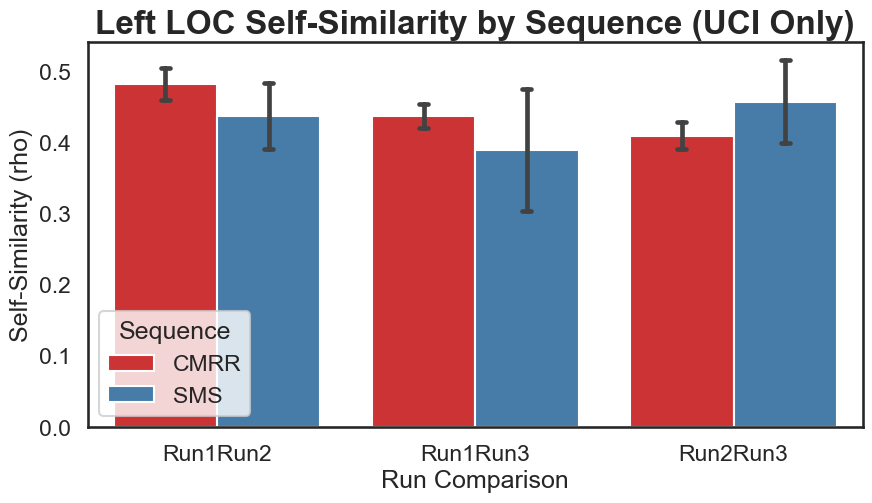

/var/folders/80/x27szhys5v384yshvf0yrws40000gn/T/ipykernel_29953/3225074986.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(['Run1Run2', 'Run1Run3', 'Run2Run3'])


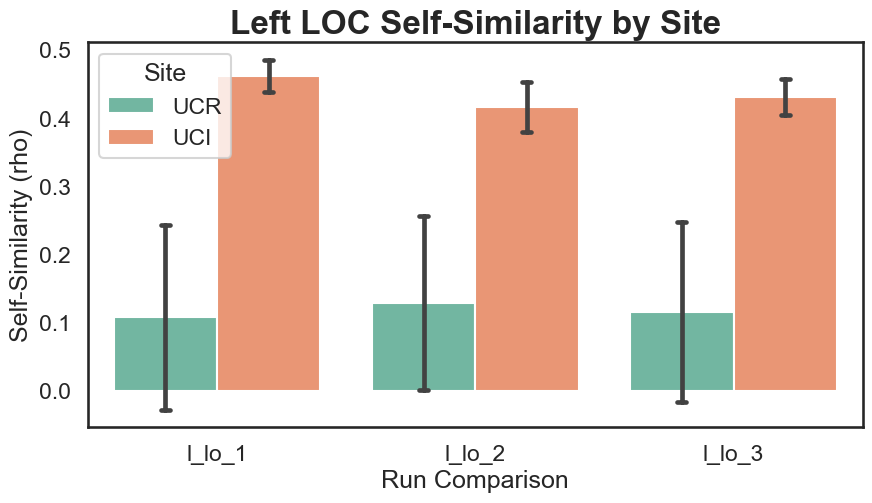

In [ ]:
sns.set_theme("talk","white")
plt.figure(figsize=(10,5))
g=sns.barplot(data=long_df[long_df['Site']=='UCI'],
            x="variable",
            y='value',
            hue='Sequence',
            errorbar='se',
            palette="Set1",
            capsize=0.07,
            hue_order=['CMRR','SMS'])
g.set_xticklabels(['Run1Run2', 'Run1Run3', 'Run2Run3'])
plt.ylabel("Self-Similarity (rho)")
plt.xlabel('Run Comparison')
plt.title("Left LOC Self-Similarity by Sequence (UCI Only)",fontweight='bold',fontsize=24)
plt.show()
plt.figure(figsize=(10,5))
h=sns.barplot(data=long_df,
            x="variable",
            y='value',
            hue='Site',
            errorbar='se',
            palette="Set2",
            capsize=0.07)
h.set_xticklabels(['Run1Run2', 'Run1Run3', 'Run2Run3'])
plt.ylabel("Self-Similarity (rho)")
plt.xlabel('Run Comparison')    
plt.title("Left LOC Self-Similarity by Site",fontweight='bold',fontsize=24)
plt.show()

In [36]:
print(smf.ols("value ~ Site + Sequence",data=long_df).fit().summary())

                            OLS Regression Results                            
Dep. Variable:                  value   R-squared:                       0.572
Model:                            OLS   Adj. R-squared:                  0.547
Method:                 Least Squares   F-statistic:                     22.10
Date:                Mon, 24 Aug 2026   Prob (F-statistic):           8.14e-07
Time:                        15:00:34   Log-Likelihood:                 25.413
No. Observations:                  36   AIC:                            -44.83
Df Residuals:                      33   BIC:                            -40.08
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.4430      0.032     